In [2]:
# ============================================
# IMPORTS
# ============================================
import os
import time
import pandas as pd
import numpy as np
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from huggingface_hub import InferenceClient

# ============================================
# API SETUP
# ============================================
# Replace 'hf_...' with your ACTUAL Hugging Face token if not set in env
HF_API_KEY = os.environ.get("HF_TOKEN", "hf_YOUR_ACTUAL_TOKEN_HERE")

# ============================================
# MODEL INITIALIZATION
# ============================================

class SentimentAnalyzer:
    def __init__(self):
        print("🔧 Initializing sentiment analyzers...")
        
        # --- 1. TextBlob (Local / Rule-based) ---
        print("✓ TextBlob ready")
        
        # --- 2. VADER (Local / Rule-based) ---
        self.vader = SentimentIntensityAnalyzer()
        print("✓ VADER ready")
        
        # --- 3. DistilBERT (Local / Standard) ---
        print("⏳ Loading DistilBERT...")
        self.distilbert = pipeline(
            "sentiment-analysis",
            model="distilbert-base-uncased-finetuned-sst-2-english",
            device=-1 # CPU
        )
        print("✓ DistilBERT ready")
        
        # --- 4. Twitter-RoBERTa (Local / Slang) ---
        print("⏳ Loading Twitter-RoBERTa...")
        self.twitter_roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1
        )
        print("✓ Twitter-RoBERTa ready")
        
        # --- 5. DeBERTa v3 (Local / Zero-Shot) ---
        print("⏳ Loading DeBERTa v3 (Local)...")
        self.deberta = pipeline(
            "zero-shot-classification",
            model="MoritzLaurer/deberta-v3-xsmall-zeroshot-v1.1-all-33",
            device=-1
        )
        print("✓ DeBERTa v3 ready")
        
        print("\n🎉 All models initialized!\n")

    # ============================================
    # ANALYZER METHODS
    # ============================================
    
    def textblob_analyze(self, text):
        polarity = TextBlob(text).sentiment.polarity
        if polarity > 0.1: return "POSITIVE", polarity
        elif polarity < -0.1: return "NEGATIVE", polarity
        else: return "NEUTRAL", polarity
    
    def vader_analyze(self, text):
        scores = self.vader.polarity_scores(text)
        compound = scores['compound']
        if compound >= 0.05: return "POSITIVE", compound
        elif compound <= -0.05: return "NEGATIVE", compound
        else: return "NEUTRAL", compound
    
    def distilbert_analyze(self, text):
        result = self.distilbert(text[:512])[0]
        label = result['label']
        score = result['score'] if label == 'POSITIVE' else -result['score']
        return label, score
    
    def twitter_roberta_analyze(self, text):
        result = self.twitter_roberta(text[:512])[0]
        label_map = {'positive': 'POSITIVE', 'negative': 'NEGATIVE', 'neutral': 'NEUTRAL'}
        label = label_map.get(result['label'].lower(), result['label'].upper())
        score = result['score'] if 'positive' in result['label'].lower() else -result['score']
        return label, score
    
    def deberta_analyze(self, text):
        result = self.deberta(text[:512], candidate_labels=["positive", "negative", "neutral"])
        label = result['labels'][0].upper()
        score = result['scores'][0] if label == 'POSITIVE' else -result['scores'][0]
        return label, score
    
    # --- ROBUST API METHODS ---

    def _chat_classify(self, text, model_id, max_retries=3):
        """Helper to use ANY Chat Model as a Classifier"""
        messages = [
            {"role": "system", "content": "Classify the sentiment of the user text. Output ONLY one word: POSITIVE, NEGATIVE, or NEUTRAL."},
            {"role": "user", "content": f"Text: {text}"}
        ]
        
        for attempt in range(max_retries):
            try:
                response = self.hf_client.chat_completion(
                    messages=messages,
                    model=model_id,
                    max_tokens=10,
                    temperature=0.1
                )
                label = response.choices[0].message.content.strip().upper()
                
                # Robust Parsing (Handles "Sentiment: POSITIVE" etc.)
                if "POSITIVE" in label: return "POSITIVE", 1.0
                if "NEGATIVE" in label: return "NEGATIVE", -1.0
                return "NEUTRAL", 0.0
            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"⚠️ API Error ({model_id}): {e}")
                    return "ERROR", 0.0
                time.sleep(1)

    def analyze_all(self, text, include_apis=True):
        results = {}
        
        # Local Models (Fast & Free)
        results['TextBlob'] = self.textblob_analyze(text)
        results['VADER'] = self.vader_analyze(text)
        results['DistilBERT'] = self.distilbert_analyze(text)
        results['Twitter-RoBERTa'] = self.twitter_roberta_analyze(text)
        results['DeBERTa (Local)'] = self.deberta_analyze(text)
        
        return results

# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":
    analyzer = SentimentAnalyzer()

    print("="*50)
    print("✅ SETUP COMPLETE!")
    print("="*50)
    print("\n🚀 Quick test (Running ALL 7 MODELS):")
    test_text = "I absolutely love this! 🔥"
    
    # This will now use Zephyr for the 7th model
    results = analyzer.analyze_all(test_text)

    for model, (label, score) in results.items():
        print(f"{model:20s}: {label:8s} (score: {score:.3f})")

🔧 Initializing sentiment analyzers...
✓ TextBlob ready
✓ VADER ready
⏳ Loading DistilBERT...


Device set to use cpu


✓ DistilBERT ready
⏳ Loading Twitter-RoBERTa...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✓ Twitter-RoBERTa ready
⏳ Loading DeBERTa v3 (Local)...


Device set to use cpu


✓ DeBERTa v3 ready

🎉 All models initialized!

✅ SETUP COMPLETE!

🚀 Quick test (Running ALL 7 MODELS):
TextBlob            : POSITIVE (score: 0.625)
VADER               : POSITIVE (score: 0.403)
DistilBERT          : POSITIVE (score: 1.000)
Twitter-RoBERTa     : POSITIVE (score: 0.985)
DeBERTa (Local)     : POSITIVE (score: 0.998)


📊 Test dataset: 23 samples
   - POSITIVE: 7
   - NEGATIVE: 11
   - NEUTRAL: 5

🔄 Running comparison on 23 texts...

[1/23] I love this product!...
  TextBlob            : POSITIVE (+0.625)
  VADER               : POSITIVE (+0.670)
  DistilBERT          : POSITIVE (+1.000)
  Twitter-RoBERTa     : POSITIVE (+0.985)
  DeBERTa (Local)     : POSITIVE (+0.997)

[2/23] This is amazing and wonderful...
  TextBlob            : POSITIVE (+0.800)
  VADER               : POSITIVE (+0.818)
  DistilBERT          : POSITIVE (+1.000)
  Twitter-RoBERTa     : POSITIVE (+0.981)
  DeBERTa (Local)     : POSITIVE (+0.999)

[3/23] Best purchase ever!...
  TextBlob            : POSITIVE (+1.000)
  VADER               : POSITIVE (+0.670)
  DistilBERT          : POSITIVE (+1.000)
  Twitter-RoBERTa     : POSITIVE (+0.977)
  DeBERTa (Local)     : POSITIVE (+0.998)

[4/23] I hate this. Terrible....
  TextBlob            : NEGATIVE (-0.900)
  VADER               : NEGATIVE (-0.809)
  DistilBERT          : NEGATIVE 

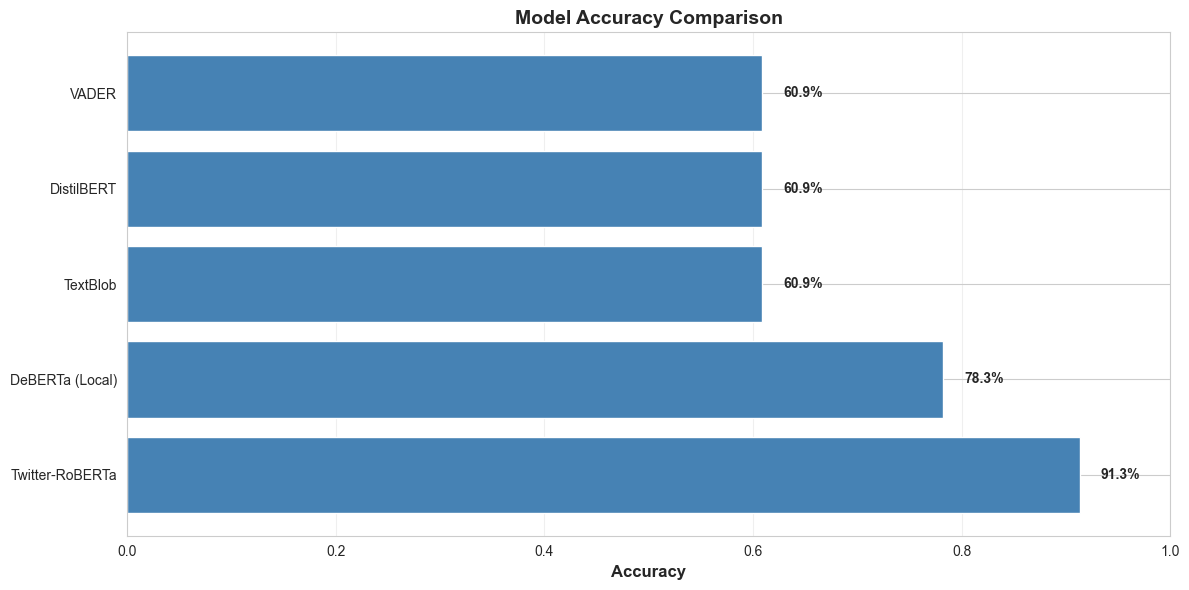

💾 Saved: sentiment_confusion_matrices.png


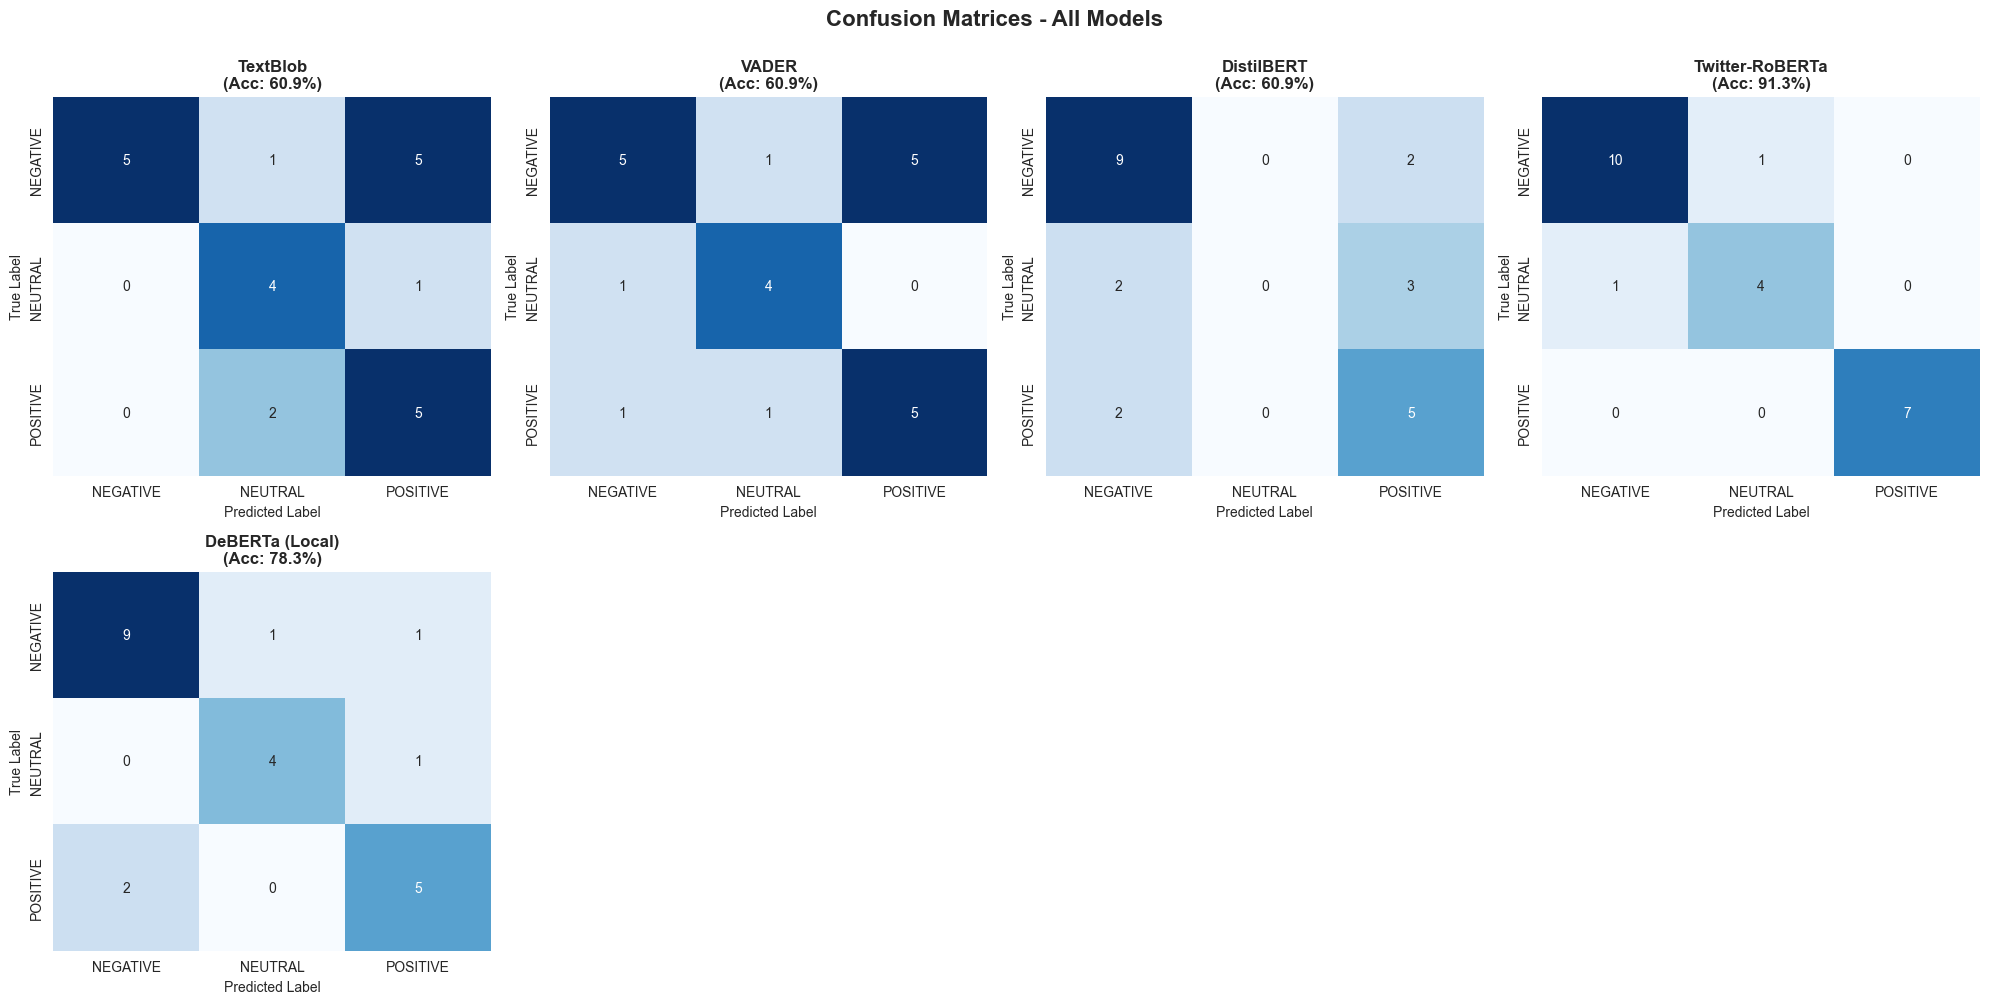

💾 Saved: sentiment_score_distribution.html


💾 Saved: sentiment_model_agreement.png


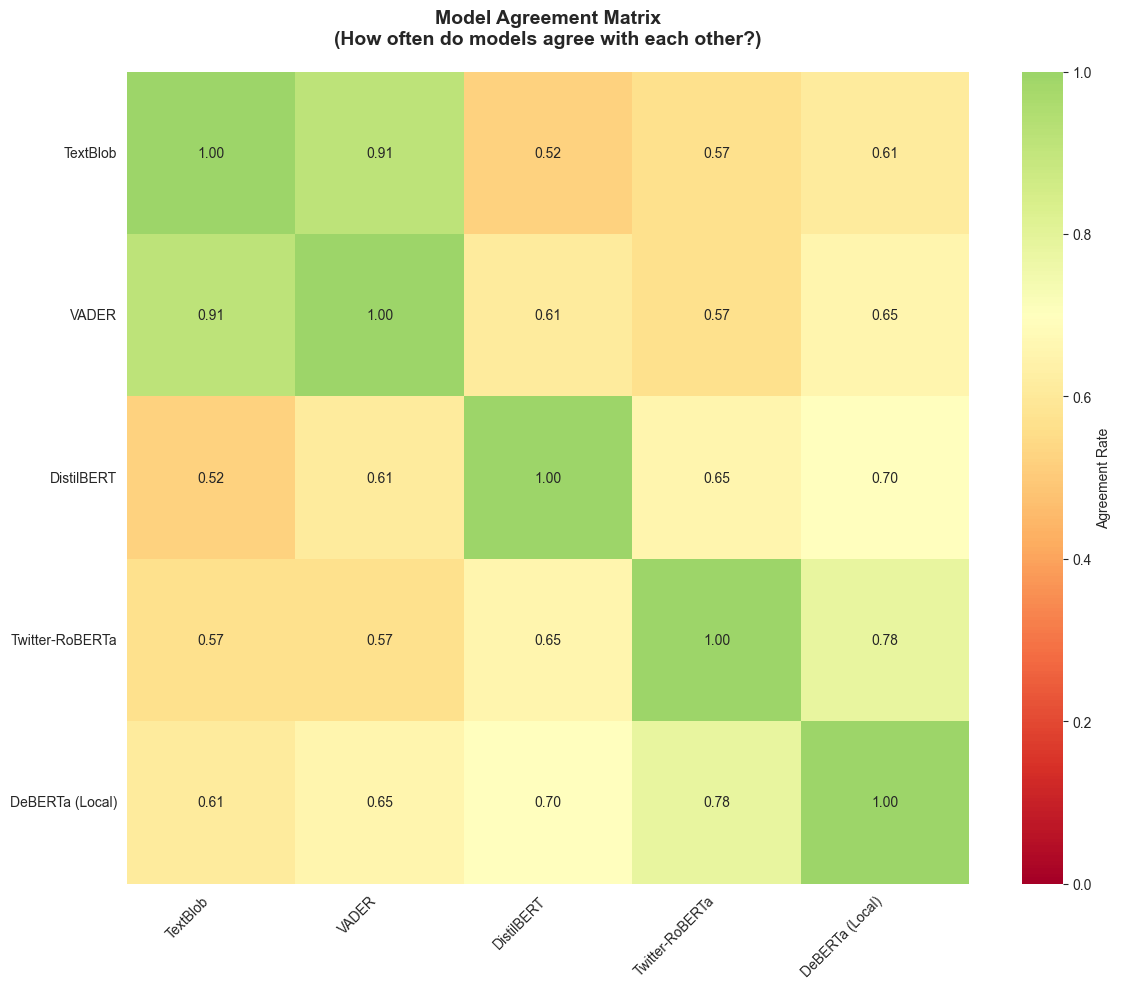

💾 Saved: sentiment_performance_by_type.html



✅ ALL VISUALIZATIONS COMPLETE!

Files saved:
  📊 sentiment_accuracy_comparison.png
  📊 sentiment_confusion_matrices.png
  📊 sentiment_score_distribution.html (interactive)
  📊 sentiment_model_agreement.png
  📊 sentiment_performance_by_type.html (interactive)
  📄 sentiment_comparison_results.csv
  📄 sentiment_metrics_summary.csv


In [4]:
# Sentiment Analysis Comparison & Visualization Script
# Run this after the setup script

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# TEST DATASET
# ============================================

# Diverse test cases covering different challenges
test_data = [
    # Simple positives
    ("I love this product!", "POSITIVE"),
    ("This is amazing and wonderful", "POSITIVE"),
    ("Best purchase ever!", "POSITIVE"),
    
    # Simple negatives
    ("I hate this. Terrible.", "NEGATIVE"),
    ("Worst experience ever", "NEGATIVE"),
    ("This is awful and disappointing", "NEGATIVE"),
    
    # Social media style (VADER's strength)
    ("THIS IS AWESOME!!! 😍🔥", "POSITIVE"),
    ("OMG this is sooo good!!!", "POSITIVE"),
    ("wtf this is trash 🗑️💩", "NEGATIVE"),
    ("worst app ever!!!!", "NEGATIVE"),
    
    # Slang (Twitter-RoBERTa's strength)
    ("This app is fire 🔥", "POSITIVE"),
    ("ngl this slaps fr fr", "POSITIVE"),
    ("This is mid tbh", "NEUTRAL"),
    ("big yikes, this is trash", "NEGATIVE"),
    
    # Sarcasm (LLM's strength)
    ("Oh great, another bug. Just what I needed.", "NEGATIVE"),
    ("Wow, amazing how it crashes every time.", "NEGATIVE"),
    ("Sure, 'working as intended' lol", "NEGATIVE"),
    
    # Mixed/Complex (LLM's strength)
    ("The design is beautiful but it crashes constantly", "NEGATIVE"),
    ("I wanted to love this but it's too buggy", "NEGATIVE"),
    ("It's okay, nothing special", "NEUTRAL"),
    
    # Neutral
    ("The product arrived on Tuesday", "NEUTRAL"),
    ("I ordered the blue one", "NEUTRAL"),
    ("It has three buttons", "NEUTRAL"),
]

# Convert to DataFrame
df_test = pd.DataFrame(test_data, columns=['text', 'true_label'])

print(f"📊 Test dataset: {len(df_test)} samples")
print(f"   - POSITIVE: {(df_test['true_label']=='POSITIVE').sum()}")
print(f"   - NEGATIVE: {(df_test['true_label']=='NEGATIVE').sum()}")
print(f"   - NEUTRAL: {(df_test['true_label']=='NEUTRAL').sum()}")

# ============================================
# RUN COMPARISON
# ============================================

def run_comparison(analyzer, df, include_apis=True, add_delay=1):
    """
    Run all models on test data and collect results
    
    Args:
        analyzer: Initialized SentimentAnalyzer
        df: DataFrame with 'text' and 'true_label' columns
        include_apis: Whether to include API-based models (costs money!)
        add_delay: Seconds to wait between API calls (avoid rate limits)
    """
    results = []
    
    print(f"\n🔄 Running comparison on {len(df)} texts...")
    print("="*60)
    
    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['true_label']
        
        print(f"\n[{idx+1}/{len(df)}] {text[:50]}...")
        
        # Get predictions from all models
        predictions = analyzer.analyze_all(text, include_apis=include_apis)
        
        # Store results
        result = {
            'text': text,
            'true_label': true_label,
        }
        
        for model_name, (pred_label, score) in predictions.items():
            result[f'{model_name}_label'] = pred_label
            result[f'{model_name}_score'] = score
            print(f"  {model_name:20s}: {pred_label:8s} ({score:+.3f})")
        
        results.append(result)
        
        # Delay for API rate limits
        if include_apis and idx < len(df) - 1:
            time.sleep(add_delay)
    
    print("\n✅ Comparison complete!")
    return pd.DataFrame(results)

# Run the comparison
# Set include_apis=False for quick testing without API costs
# RECOMMENDATION: Start with False, then enable True only if you have valid API keys
df_results = run_comparison(analyzer, df_test, include_apis=True, add_delay=1)

# ============================================
# CALCULATE METRICS
# ============================================

model_names = ['TextBlob', 'VADER', 'DistilBERT', 'Twitter-RoBERTa', 
               'DeBERTa (Local)', ]

metrics_summary = []

for model in model_names:
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        y_true = df_results['true_label']
        y_pred = df_results[label_col]
        
        # Calculate accuracy
        accuracy = accuracy_score(y_true, y_pred)
        
        # Count correct predictions per class
        correct_pos = ((y_true == 'POSITIVE') & (y_pred == 'POSITIVE')).sum()
        correct_neg = ((y_true == 'NEGATIVE') & (y_pred == 'NEGATIVE')).sum()
        correct_neu = ((y_true == 'NEUTRAL') & (y_pred == 'NEUTRAL')).sum()
        
        total_pos = (y_true == 'POSITIVE').sum()
        total_neg = (y_true == 'NEGATIVE').sum()
        total_neu = (y_true == 'NEUTRAL').sum()
        
        metrics_summary.append({
            'Model': model,
            'Accuracy': accuracy,
            'Correct_Positive': f"{correct_pos}/{total_pos}",
            'Correct_Negative': f"{correct_neg}/{total_neg}",
            'Correct_Neutral': f"{correct_neu}/{total_neu}",
        })

df_metrics = pd.DataFrame(metrics_summary)
df_metrics = df_metrics.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📈 MODEL PERFORMANCE SUMMARY")
print("="*60)
print(df_metrics.to_string(index=False))

# ============================================
# VISUALIZATION 1: Accuracy Comparison
# ============================================

fig1, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.barh(df_metrics['Model'], df_metrics['Accuracy'], color='steelblue')
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, df_metrics['Accuracy'])):
    ax1.text(acc + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{acc:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: sentiment_accuracy_comparison.png")
plt.show()

# ============================================
# VISUALIZATION 2: Confusion Matrices
# ============================================

# OPTIONAL PRO TIP: Change (2, 4) to (2, 3) below for a tighter layout 
# since you only have 5 models. (2x3 = 6 slots, only 1 empty)
fig2, axes = plt.subplots(2, 4, figsize=(20, 10)) 
axes = axes.flatten()

labels = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

for idx, model in enumerate(model_names):
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        cm = confusion_matrix(df_results['true_label'], 
                              df_results[label_col], 
                              labels=labels)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=labels, yticklabels=labels,
                   ax=axes[idx], cbar=False)
        
        # Add accuracy score to title
        acc = df_metrics[df_metrics["Model"]==model]["Accuracy"].values[0]
        axes[idx].set_title(f'{model}\n(Acc: {acc:.1%})', fontweight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

# --- THIS IS THE FIX ---
# Loop through all remaining axes (from len(model_names) to the end) and turn them off
for i in range(len(model_names), len(axes)):
    axes[i].axis('off')
# -----------------------

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('sentiment_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_confusion_matrices.png")
plt.show()

# ============================================
# VISUALIZATION 3: Interactive Score Distribution
# ============================================

fig3 = make_subplots(
    rows=2, cols=4,
    subplot_titles=model_names,
    specs=[[{'type': 'box'}]*4, [{'type': 'box'}]*4]
)

colors = {'POSITIVE': 'green', 'NEGATIVE': 'red', 'NEUTRAL': 'gray'}

for idx, model in enumerate(model_names):
    row = idx // 4 + 1
    col = idx % 4 + 1
    score_col = f'{model}_score'
    
    if score_col in df_results.columns:
        for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
            mask = df_results['true_label'] == sentiment
            scores = df_results[mask][score_col]
            
            fig3.add_trace(
                go.Box(y=scores, name=sentiment, marker_color=colors[sentiment],
                      showlegend=(idx==0)),
                row=row, col=col
            )

fig3.update_layout(
    title_text="Score Distribution by True Sentiment (All Models)",
    height=800,
    showlegend=True
)

fig3.write_html('sentiment_score_distribution.html')
print("💾 Saved: sentiment_score_distribution.html")
fig3.show()

# ============================================
# VISUALIZATION 4: Model Agreement Heatmap
# ============================================

# Calculate agreement matrix
agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        if i == j:
            agreement_matrix[i][j] = 1.0
        else:
            col1 = f'{model1}_label'
            col2 = f'{model2}_label'
            if col1 in df_results.columns and col2 in df_results.columns:
                agreement = (df_results[col1] == df_results[col2]).mean()
                agreement_matrix[i][j] = agreement

fig4, ax4 = plt.subplots(figsize=(12, 10))
sns.heatmap(agreement_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
           xticklabels=model_names, yticklabels=model_names,
           vmin=0, vmax=1, center=0.7, ax=ax4, cbar_kws={'label': 'Agreement Rate'})
ax4.set_title('Model Agreement Matrix\n(How often do models agree with each other?)', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_model_agreement.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_model_agreement.png")
plt.show()

# ============================================
# VISUALIZATION 5: Performance by Text Type
# ============================================

# Categorize texts
def categorize_text(text):
    text_lower = text.lower()
    if any(x in text for x in ['!!!', '🔥', '😍', '💩', '🗑️']):
        return 'Social Media'
    elif any(x in text_lower for x in ['fire', 'slaps', 'yikes', 'mid', 'ngl', 'fr']):
        return 'Slang'
    elif any(x in text_lower for x in ['oh great', 'wow, amazing', 'sure,', 'lol']):
        return 'Sarcasm'
    elif 'but' in text_lower or ('.' in text and len(text) > 40):
        return 'Complex'
    elif any(x in text_lower for x in ['arrived', 'ordered', 'has']):
        return 'Neutral'
    else:
        return 'Simple'

df_results['text_type'] = df_results['text'].apply(categorize_text)

# Calculate accuracy by text type
type_performance = []
for text_type in df_results['text_type'].unique():
    mask = df_results['text_type'] == text_type
    for model in model_names:
        label_col = f'{model}_label'
        if label_col in df_results.columns:
            acc = accuracy_score(
                df_results[mask]['true_label'],
                df_results[mask][label_col]
            )
            type_performance.append({
                'Text Type': text_type,
                'Model': model,
                'Accuracy': acc
            })

df_type_perf = pd.DataFrame(type_performance)

fig5 = px.bar(df_type_perf, x='Text Type', y='Accuracy', color='Model',
             barmode='group', title='Model Performance by Text Type',
             height=600)
fig5.update_layout(yaxis_range=[0, 1])
fig5.write_html('sentiment_performance_by_type.html')
print("💾 Saved: sentiment_performance_by_type.html")
fig5.show()

# ============================================
# SAVE RESULTS
# ============================================

df_results.to_csv('sentiment_comparison_results.csv', index=False)
df_metrics.to_csv('sentiment_metrics_summary.csv', index=False)

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*60)
print("\nFiles saved:")
print("  📊 sentiment_accuracy_comparison.png")
print("  📊 sentiment_confusion_matrices.png")
print("  📊 sentiment_score_distribution.html (interactive)")
print("  📊 sentiment_model_agreement.png")
print("  📊 sentiment_performance_by_type.html (interactive)")
print("  📄 sentiment_comparison_results.csv")
print("  📄 sentiment_metrics_summary.csv")